<a href="https://colab.research.google.com/github/LarsVoermans/master-thesis-pead/blob/main/McNemartest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

In [ ]:
from google.colab import files
uploaded = files.upload()  # er verschijnt een knop om bestanden te kiezen

Saving overzicht_rf_resultaten.csv to overzicht_rf_resultaten.csv
Saving overzicht_lr_resultaten_v2.csv to overzicht_lr_resultaten_v2 (2).csv
Saving overzicht_xgb_resultaten.csv to overzicht_xgb_resultaten (2).csv


In [ ]:
overzicht_xgb_nieuw = pd.read_csv('overzicht_xgb_resultaten.csv')
overzicht_lr_nieuw = pd.read_csv('overzicht_lr_resultaten_v2.csv')
overzicht_RF_nieuw = pd.read_csv('overzicht_rf_resultaten.csv')

In [ ]:
# McNemar test XGB
lengte_xgb = len(overzicht_xgb_nieuw)
lengte_lr = len(overzicht_lr_nieuw)

print(f"Aantal rijen in XGBoost bestand: {lengte_xgb}")
print(f"Aantal rijen in Logistic Regression bestand: {lengte_lr}\n")

if lengte_xgb != lengte_lr:
    raise ValueError(
        f"FOUT: De bestanden zijn niet even lang! (XGB: {lengte_xgb}, LR: {lengte_lr}). "
        "Zorg ervoor dat beide modellen op exact dezelfde testset zijn geëvalueerd voordat je McNemar draait."
    )
else:
    print("✓ Check geslaagd: Beide bestanden zijn exact even lang. We kunnen door!\n")

lr_status = overzicht_lr_nieuw['Resultaat'].values
xgb_status = overzicht_xgb_nieuw['Resultaat'].values

beide_goed = np.sum((lr_status == 'GOED') & (xgb_status == 'GOED'))
lr_goed_xgb_fout = np.sum((lr_status == 'GOED') & (xgb_status == 'FOUT'))
lr_fout_xgb_goed = np.sum((lr_status == 'FOUT') & (xgb_status == 'GOED'))
beide_fout = np.sum((lr_status == 'FOUT') & (xgb_status == 'FOUT'))

mcnemar_table = [
    [beide_goed, lr_goed_xgb_fout],
    [lr_fout_xgb_goed, beide_fout]
]

print("=== MCNEMAR CONTINGENTIETABEL ===")
print(f"               [ XGB Goed ]  [ XGB Fout ]")
print(f"[ LR Goed ]       {beide_goed:<12} {lr_goed_xgb_fout:<12}")
print(f"[ LR Fout ]       {lr_fout_xgb_goed:<12} {beide_fout:<12}\n")

result = mcnemar(mcnemar_table, exact=False, correction=True)

print("=== RESULTAAT MCNEMAR TEST ===")
print(f"p-waarde: {result.pvalue}")

if result.pvalue < 0.05:
    print("\nCONCLUSIE: Het verschil tussen LR en XGBoost is STATISTISCH SIGNIFICANT! (p < 0.05)")
    if lr_fout_xgb_goed > lr_goed_xgb_fout:
        print("XGBoost presteert significant beter dan Logistic Regression.")
    else:
        print("Logistic Regression presteert significant beter dan XGBoost.")
else:
    print("\nCONCLUSIE: Er is GEEN statistisch significant verschil tussen de modellen (p >= 0.05).")

Aantal rijen in XGBoost bestand: 1292
Aantal rijen in Logistic Regression bestand: 1292

✓ Check geslaagd: Beide bestanden zijn exact even lang. We kunnen door!

=== MCNEMAR CONTINGENTIETABEL ===
               [ XGB Goed ]  [ XGB Fout ]
[ LR Goed ]       326          206         
[ LR Fout ]       407          353         

=== RESULTAAT MCNEMAR TEST ===
p-waarde: 6.587868535912356e-16

CONCLUSIE: Het verschil tussen LR en XGBoost is STATISTISCH SIGNIFICANT! (p < 0.05)
XGBoost presteert significant beter dan Logistic Regression.


In [ ]:
# McNemar RF
lengte_rf = len(overzicht_RF_nieuw)
lengte_lr = len(overzicht_lr_nieuw)

print(f"Aantal rijen in Random Forest bestand: {lengte_rf}")
print(f"Aantal rijen in Logistic Regression bestand: {lengte_lr}\n")

if lengte_rf != lengte_lr:
    raise ValueError(
        f"FOUT: De bestanden zijn niet even lang! (RF: {lengte_rf}, LR: {lengte_lr}). "
        "Zorg ervoor dat beide modellen op exact dezelfde testset zijn geëvalueerd voordat je McNemar draait."
    )
else:
    print("✓ Check geslaagd: Beide bestanden zijn exact even lang. We kunnen door!\n")

lr_status = overzicht_lr_nieuw['Resultaat'].values
rf_status = overzicht_RF_nieuw['Resultaat'].values

beide_goed = np.sum((lr_status == 'GOED') & (rf_status == 'GOED'))
lr_goed_rf_fout = np.sum((lr_status == 'GOED') & (rf_status == 'FOUT'))
lr_fout_rf_goed = np.sum((lr_status == 'FOUT') & (rf_status == 'GOED'))
beide_fout = np.sum((lr_status == 'FOUT') & (rf_status == 'FOUT'))

mcnemar_table = [
    [beide_goed, lr_goed_rf_fout],
    [lr_fout_rf_goed, beide_fout]
]

print("=== MCNEMAR CONTINGENTIETABEL ===")
print(f"               [ RF Goed ]   [ RF Fout ]")
print(f"[ LR Goed ]       {beide_goed:<12} {lr_goed_rf_fout:<12}")
print(f"[ LR Fout ]       {lr_fout_rf_goed:<12} {beide_fout:<12}\n")

result = mcnemar(mcnemar_table, exact=False, correction=True)

print("=== RESULTAAT MCNEMAR TEST ===")
print(f"p-waarde: {result.pvalue}")

if result.pvalue < 0.05:
    print("\nCONCLUSIE: Het verschil tussen LR en Random Forest is STATISTISCH SIGNIFICANT! (p < 0.05)")
    if lr_fout_rf_goed > lr_goed_rf_fout:
        print("Random Forest presteert significant beter dan Logistic Regression.")
    else:
        print("Logistic Regression presteert significant beter dan Random Forest.")
else:
    print("\nCONCLUSIE: Er is GEEN statistisch significant verschil tussen de modellen (p >= 0.05).")

Aantal rijen in Random Forest bestand: 1292
Aantal rijen in Logistic Regression bestand: 1292

✓ Check geslaagd: Beide bestanden zijn exact even lang. We kunnen door!

=== MCNEMAR CONTINGENTIETABEL ===
               [ RF Goed ]   [ RF Fout ]
[ LR Goed ]       360          172         
[ LR Fout ]       361          399         

=== RESULTAAT MCNEMAR TEST ===
p-waarde: 3.8501667851151975e-16

CONCLUSIE: Het verschil tussen LR en Random Forest is STATISTISCH SIGNIFICANT! (p < 0.05)
Random Forest presteert significant beter dan Logistic Regression.


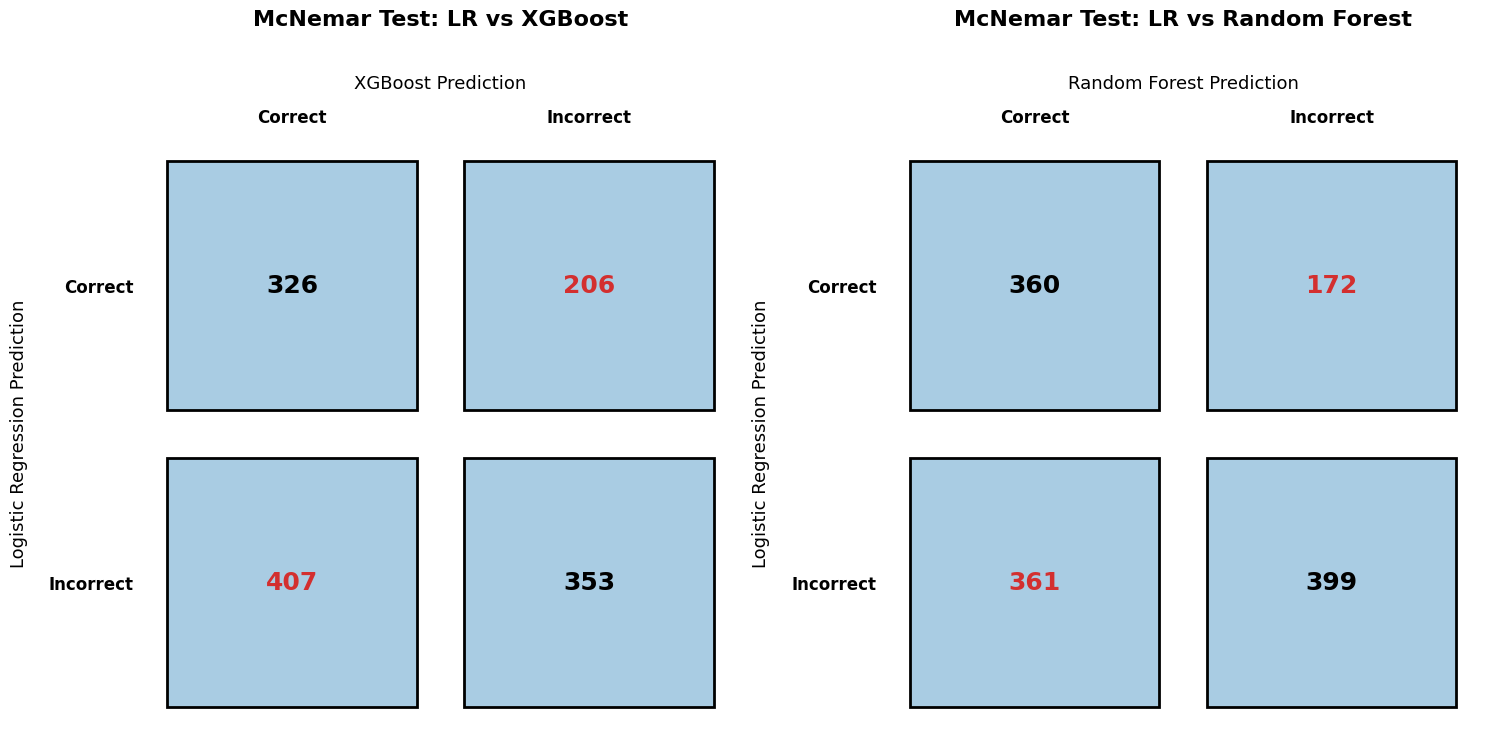

In [ ]:

# --- 1. LOAD DATA ---
overzicht_lr = pd.read_csv('overzicht_lr_resultaten_v2.csv')
overzicht_xgb = pd.read_csv('overzicht_xgb_resultaten.csv')
overzicht_rf = pd.read_csv('overzicht_rf_resultaten.csv')

# --- 2. EXTRACT VALUES ---
lr_status = overzicht_lr['Resultaat'].values
xgb_status = overzicht_xgb['Resultaat'].values
rf_status = overzicht_rf['Resultaat'].values

# Calculate Matrix 1: LR vs XGBoost
m_xgb = np.array([
    [np.sum((lr_status == 'GOED') & (xgb_status == 'GOED')), np.sum((lr_status == 'GOED') & (xgb_status == 'FOUT'))],
    [np.sum((lr_status == 'FOUT') & (xgb_status == 'GOED')), np.sum((lr_status == 'FOUT') & (xgb_status == 'FOUT'))]
])

# Calculate Matrix 2: LR vs Random Forest
m_rf = np.array([
    [np.sum((lr_status == 'GOED') & (rf_status == 'GOED')), np.sum((lr_status == 'GOED') & (rf_status == 'FOUT'))],
    [np.sum((lr_status == 'FOUT') & (rf_status == 'GOED')), np.sum((lr_status == 'FOUT') & (rf_status == 'FOUT'))]
])

# --- 3. PLOTTING THE FIGURES ---
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
labels = ['Correct', 'Incorrect']
custom_blue = '#A9CCE3'  # Een mooie, duidelijke egale kleur blauw voor alle vakken

for idx, (ax, matrix, title, xlabel) in enumerate([
    (axes[0], m_xgb, 'McNemar Test: LR vs XGBoost', 'XGBoost Prediction'),
    (axes[1], m_rf, 'McNemar Test: LR vs Random Forest', 'Random Forest Prediction')
]):

    # Basis instellingen voor de assen (leeg canvas maken)
    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0) # Omgedraaid zodat 0,0 linksboven zit
    ax.set_aspect('equal')

    # Assen aan de bovenkant en linkerkant zetten
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Labels en titels toevoegen
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(labels, fontsize=12, fontweight='bold')

    ax.set_title(title, fontsize=16, fontweight='bold', pad=35)
    ax.set_xlabel(xlabel, fontsize=13, labelpad=15)
    ax.set_ylabel('Logistic Regression Prediction', fontsize=13, labelpad=15)

    # Haal de standaard lelijke box-lijntjes van matplotlib weg
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(top=False, left=False) # Verberg kleine streepjes bij de labels

    # Teken de 4 losse vakken met exact dezelfde kleur blauw en voeg tekst toe
    for i in range(2):
        for j in range(2):
            # Teken het blauwe vlak met een zwart randje eromheen
            # 0.08 en 0.84 zorgen voor de perfecte witruimte/gaps tussen de vakken
            rect = patches.Rectangle(
                (j + 0.08, i + 0.08), 0.84, 0.84,
                linewidth=2, edgecolor='black', facecolor=custom_blue
            )
            ax.add_patch(rect)

            # Bepaal de tekstkleur: Rechtsboven (0,1) en Linksonder (1,0) worden ROOD
            if i != j:
                text_color = '#D32F2F'  # Rood voor de 'mismatches'
            else:
                text_color = 'black'    # Zwart voor de 'matches'

            # Schrijf de waarde in het midden van het vakje
            ax.text(j + 0.5, i + 0.5, f'{matrix[i, j]}',
                    ha='center', va='center', color=text_color, fontsize=18, fontweight='bold')

# Lay-out strak trekken en tonen
plt.tight_layout()
plt.show()

# Sla het uiteindelijke perfecte figuur op
fig.savefig('mcnemar_plots_perfect_blue.png', dpi=300)